# Model 1 - Own CNN-model


In [5]:
import os, pathlib
os.environ["KERAS_BACKEND"] = "tensorflow"

import matplotlib.pyplot as plt
import keras
from keras import layers
from keras.utils import image_dataset_from_directory

This notebook covers the creation of our own CNN-model. The model is trained with the images taken by us.

Images can be found in the `2-Kuvantunnistus/images`- folder. 

The image dataset contains 5 classes, and they've been split into three sets (70%/15%/15%). 70% for training, 15% for validation and the last 15% for testing.

The 5 classes of images are:
- forks
- knives
- mugs
- pens
- spoons

In [6]:
batch_size = 32
img_size = (224, 224) # every image is 224x224 pixels

train_dataset = image_dataset_from_directory(
    "images/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

validation_dataset = image_dataset_from_directory(
    "images/validation",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_dataset = image_dataset_from_directory(
    "images/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

Found 175 files belonging to 5 classes.
Found 35 files belonging to 5 classes.
Found 40 files belonging to 5 classes.


In [3]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        layers.RandomTranslation(0.1, 0.1),
    ]
)

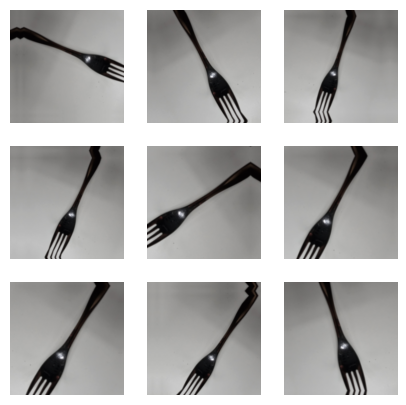

In [4]:
plt.figure(figsize=(5, 5))
for images, _ in train_dataset.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images, training=True)
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")